# Lithium-Ion Battery State of Health Prediction
**Data:** NASA Prognostics Center of Excellence (PCoE) battery aging dataset, cells B0005, B0006, B0007, B0018

**Question:** Can we estimate how much capacity a lithium-ion cell has left, for a cell the model has never seen, using signals that are cheap to measure during normal operation?

**Approach:** restructure 2 million raw measurements into cycle-level tables, clean them, engineer health indicators that do not leak the answer, and compare three models under leave-one-battery-out validation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display

from src.data_processing import BATTERIES, EOL_CAPACITY_AH, clean_cycle_table, load_battery, to_timeseries
from src.features import FEATURE_COLUMNS, FEATURE_DESCRIPTIONS, build_cycle_table
from src.modeling import feature_importance, leave_one_battery_out
from src import visualize as viz

DATA_DIR = Path("../data")
FIG_DIR = Path("../outputs/figures")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

## 1. Load and restructure the raw data
Each `.mat` file is a nested MATLAB struct: one battery, a list of cycles (charge, discharge, impedance), and arrays of time-series readings inside each cycle. The first step flattens that into a long table so it can be explored with pandas.

In [2]:
cycles = {b: load_battery(DATA_DIR / f"{b}.mat", b) for b in BATTERIES}
ts = pd.concat([to_timeseries(c, b) for b, c in cycles.items()], ignore_index=True)
print(f"{len(ts):,} raw measurements")
ts.groupby(["battery_id", "cycle_type"]).raw_cycle_index.nunique().unstack()

2,089,050 raw measurements


cycle_type,charge,discharge
battery_id,,
B0005,170,168
B0006,170,168
B0007,170,168
B0018,134,132


In [3]:
ts.head()

,battery_id,raw_cycle_index,cycle_type,time_s,voltage_v,current_a,temperature_c
0,B0005,0,charge,0.000,3.873017,-0.001201,24.655358
1,B0005,0,charge,2.532,3.479394,-4.030268,24.666480
2,B0005,0,charge,5.500,4.000588,1.512731,24.675394
3,B0005,0,charge,8.344,4.012395,1.509063,24.693865
4,B0005,0,charge,11.125,4.019708,1.511318,24.705069


## 2. Engineer health indicators (without leaking the target)
Capacity equals discharge current multiplied by full discharge time, so using full discharge time (or anything that only happens at the end of a discharge, like the temperature peak) would let the model read the answer instead of learning it. Every feature below comes from the **charge cycle before** the discharge or from an **early, partial window** of the discharge.

In [4]:
pd.Series(FEATURE_DESCRIPTIONS, name="description").to_frame()

,description
cc_charge_time_s,Seconds in constant-current charging before vo...
cv_charge_time_s,Seconds in constant-voltage charging until cur...
v_drop_time_3p8_3p5_s,Seconds for discharge voltage to fall from 3.8...
voltage_at_500s_v,Discharge voltage 500 s into the cycle
voltage_at_1000s_v,Discharge voltage 1000 s into the cycle
temp_rise_first_1000s_c,Temperature rise (C) in the first 1000 s of di...
initial_voltage_sag_v,Voltage drop in the first few seconds of disch...


In [5]:
raw = pd.concat([build_cycle_table(c, b) for b, c in cycles.items()], ignore_index=True)
raw.head()

,battery_id,cycle_number,raw_cycle_index,cutoff_voltage_v,capacity_ah,cc_charge_time_s,cv_charge_time_s,charge_start_voltage_v,v_drop_time_3p8_3p5_s,voltage_at_500s_v,voltage_at_1000s_v,temp_rise_first_1000s_c,initial_voltage_sag_v,soh_pct
0,B0005,1,1,2.7,1.856487,667.891,3564.437,3.873017,1641.360,3.774600,3.663357,6.368854,0.000743,101.151728
1,B0005,2,3,2.7,1.846327,3241.797,3800.359,3.325055,1680.125,3.780129,3.667811,6.168964,0.000892,100.598145
2,B0005,3,5,2.7,1.835349,3238.719,3739.890,3.352604,1680.657,3.782111,3.669361,6.064243,0.000988,100.000000
3,B0005,4,7,2.7,1.835263,3229.203,3746.828,3.378799,1681.765,3.783895,3.670782,6.013031,0.000709,99.995278
4,B0005,5,9,2.7,1.834646,3228.218,3696.188,3.372871,1680.782,3.784795,3.671123,6.001563,0.000914,99.961659


## 3. Clean the data
Three data quality issues showed up during exploration:

1. **Abnormal charge cycles.** Some charges did not start from a fully discharged cell (top-up charges, and the very first charge of each experiment). Their constant-current phase is much shorter, so their timings do not describe battery health. A charge is flagged only when it started at an unusually high voltage **and** its charge time jumped away from neighboring cycles; requiring both keeps real capacity regeneration after rest periods in the data. Flagged values are interpolated from neighboring cycles of the same battery. Capacity is never used in this step.
2. **Capacity measurement glitches.** Rare spikes far from the local rolling median are dropped.
3. **A misleading feature.** Charge temperature rise was tested and removed: charges often begin while the cell is still warm from the previous discharge, so it cools during charging and the "rise" measures rest time, not health (it read 0 for 101 of 132 B0018 cycles).

In [6]:
df, log = clean_cycle_table(raw)
log

{'rows_in': 636,
 'abnormal_charge_cycles_reset': 14,
 'missing_charge_features_filled': 17,
 'capacity_outliers_dropped': 2,
 'rows_with_missing_dropped': 0,
 'rows_out': 634}

## 4. Explore

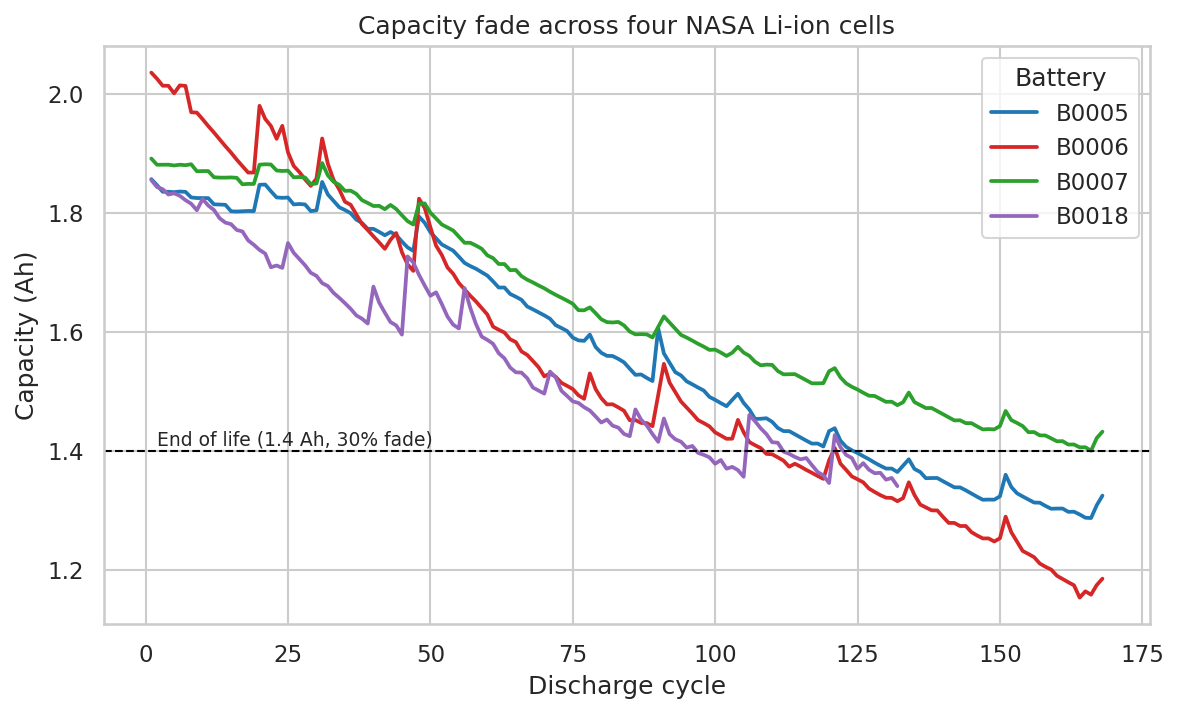

In [7]:
viz.plot_capacity_fade(df, FIG_DIR)
display(Image(FIG_DIR / "01_capacity_fade.png"))

All four cells lose capacity steadily, with small upward jumps after rest periods (capacity regeneration). B0006 starts highest and fades fastest, crossing the 1.4 Ah end-of-life line around cycle 109; B0007 never reaches it.

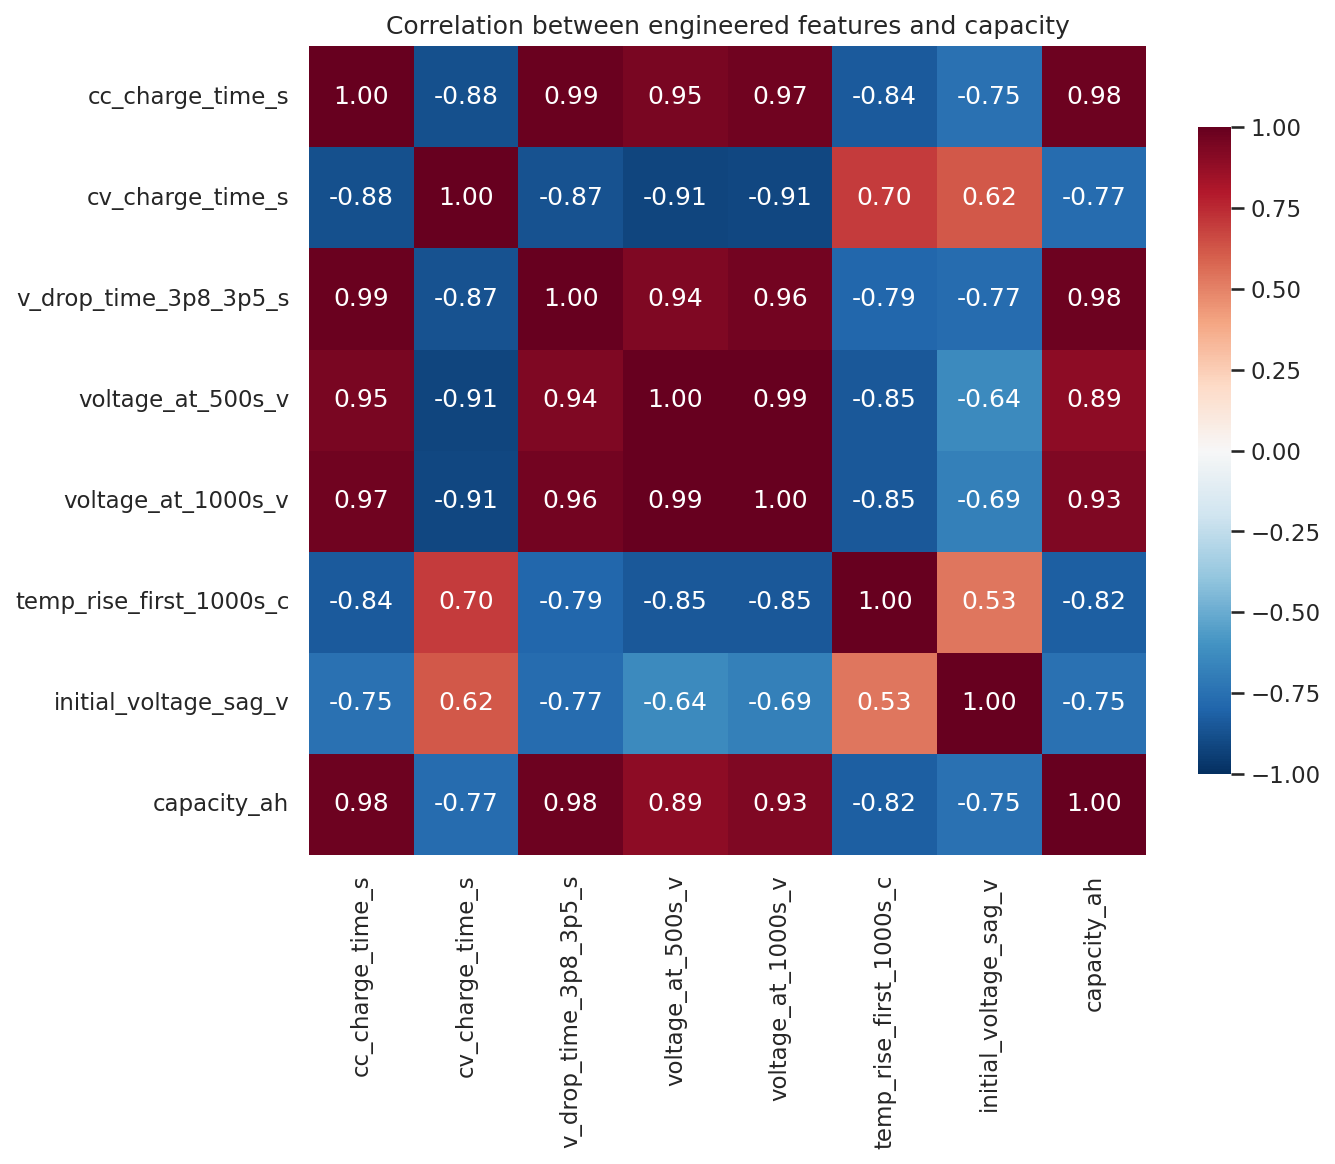

In [8]:
viz.plot_feature_correlations(df, FEATURE_COLUMNS, FIG_DIR)
display(Image(FIG_DIR / "02_feature_correlations.png"))

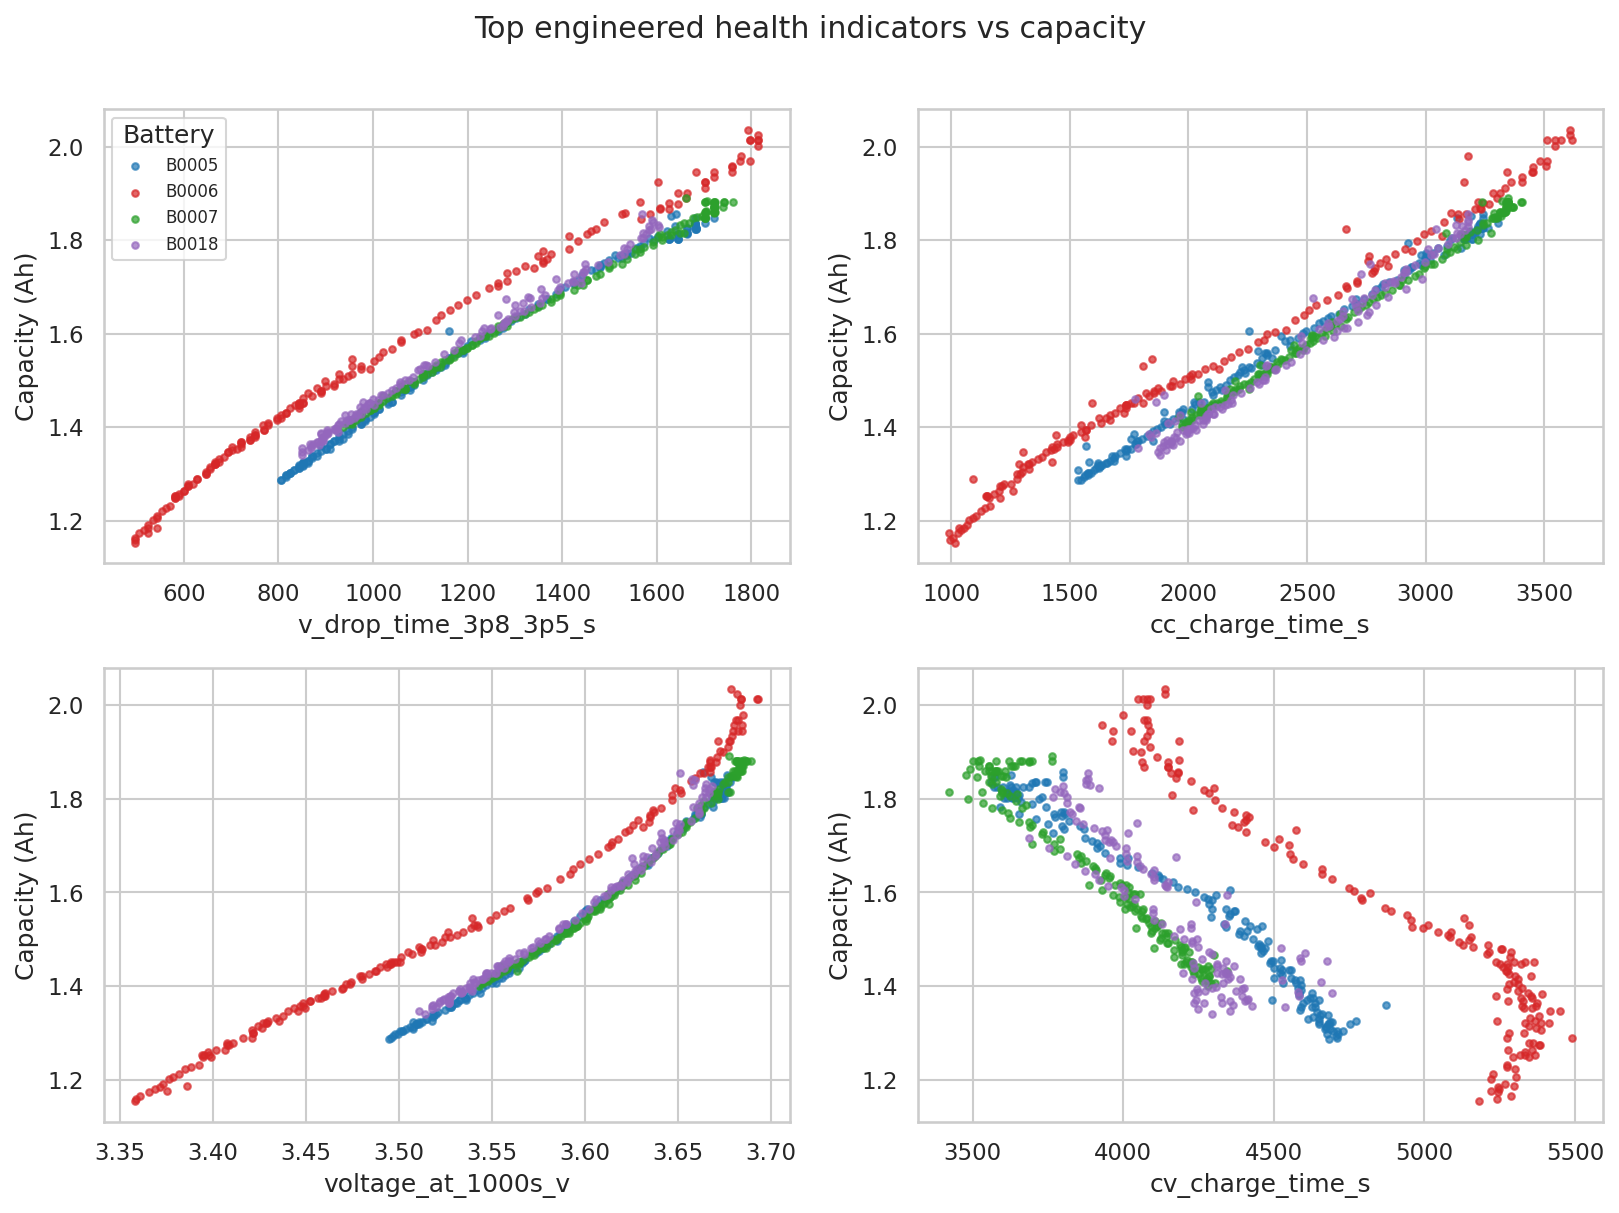

In [9]:
importance = feature_importance(df, FEATURE_COLUMNS, "Linear Regression")
viz.plot_features_vs_capacity(df, list(importance.index), FIG_DIR)
display(Image(FIG_DIR / "03_features_vs_capacity.png"))

The discharge features track capacity closely **within** each battery, but B0006 sits on a shifted curve: at the same voltage behavior it holds more capacity. That offset is cell-to-cell variation, and it matters for generalizing to new cells. The constant-current charge time lines up much more consistently across all four batteries.

## 5. Model with leave-one-battery-out validation
A random train/test split would put neighboring cycles of the same battery on both sides, and the model would score well just by interpolating. Instead, each model is trained on three batteries and tested on the fourth, repeated for all four. Three feature sets are compared to see which signals actually generalize.

In [10]:
charge = ["cc_charge_time_s", "cv_charge_time_s"]
feature_sets = {
    "Charge only (2)": charge,
    "Discharge only (5)": [f for f in FEATURE_COLUMNS if f not in charge],
    "All features (7)": FEATURE_COLUMNS,
}
metrics, preds = [], []
for name, feats in feature_sets.items():
    m, p = leave_one_battery_out(df, feats)
    metrics.append(m.assign(feature_set=name)); preds.append(p.assign(feature_set=name))
metrics, preds = pd.concat(metrics), pd.concat(preds)
summary = (metrics.groupby(["feature_set", "model"])[["rmse_ah", "mae_ah", "mape_pct", "r2"]]
           .mean().reset_index().sort_values("rmse_ah"))
summary.round(4)

,feature_set,model,rmse_ah,mae_ah,mape_pct,r2
3,Charge only (2),Linear Regression,0.0237,0.0186,1.2178,0.9824
0,All features (7),Linear Regression,0.0403,0.0373,2.5261,0.9544
4,Charge only (2),Random Forest,0.0440,0.0358,2.3888,0.9472
2,All features (7),XGBoost,0.0506,0.0426,2.8255,0.9232
6,Discharge only (5),Linear Regression,0.0566,0.0532,3.5274,0.8951
8,Discharge only (5),XGBoost,0.0601,0.0495,3.2747,0.8949
1,All features (7),Random Forest,0.0627,0.0512,3.3893,0.8786
7,Discharge only (5),Random Forest,0.0712,0.0574,3.7930,0.8427
5,Charge only (2),XGBoost,0.0844,0.0652,4.2947,0.8023


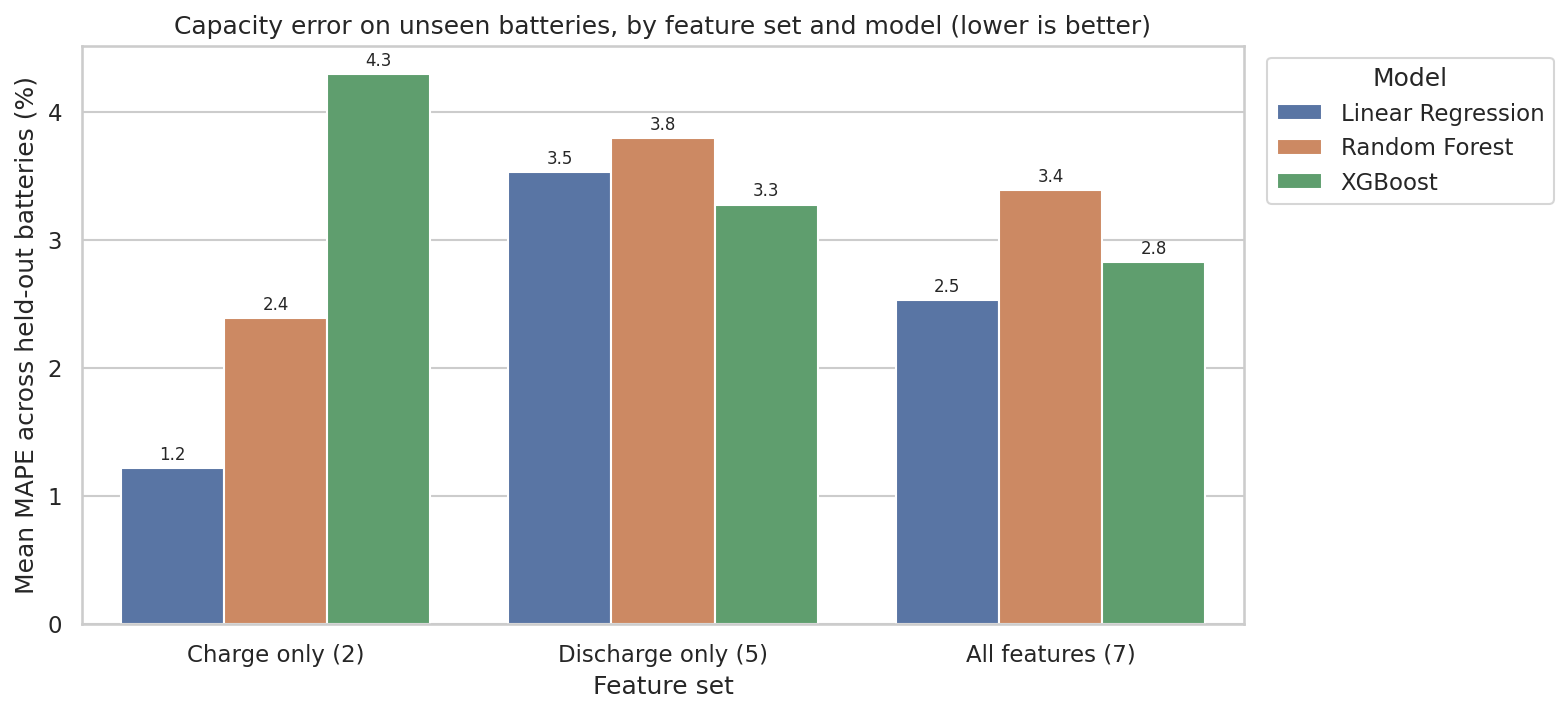

In [11]:
viz.plot_model_comparison(summary, FIG_DIR, order=list(feature_sets))
display(Image(FIG_DIR / "04_model_comparison.png"))

**Key finding: two simple charge features beat all seven combined.** The discharge features carry battery-specific offsets (like B0006's shifted curve) that do not transfer to a new cell, so adding them makes predictions on unseen batteries worse. The tree models also struggle here because they cannot predict values outside the range they were trained on, and with only three training batteries that range is narrow. Linear Regression extrapolates naturally.

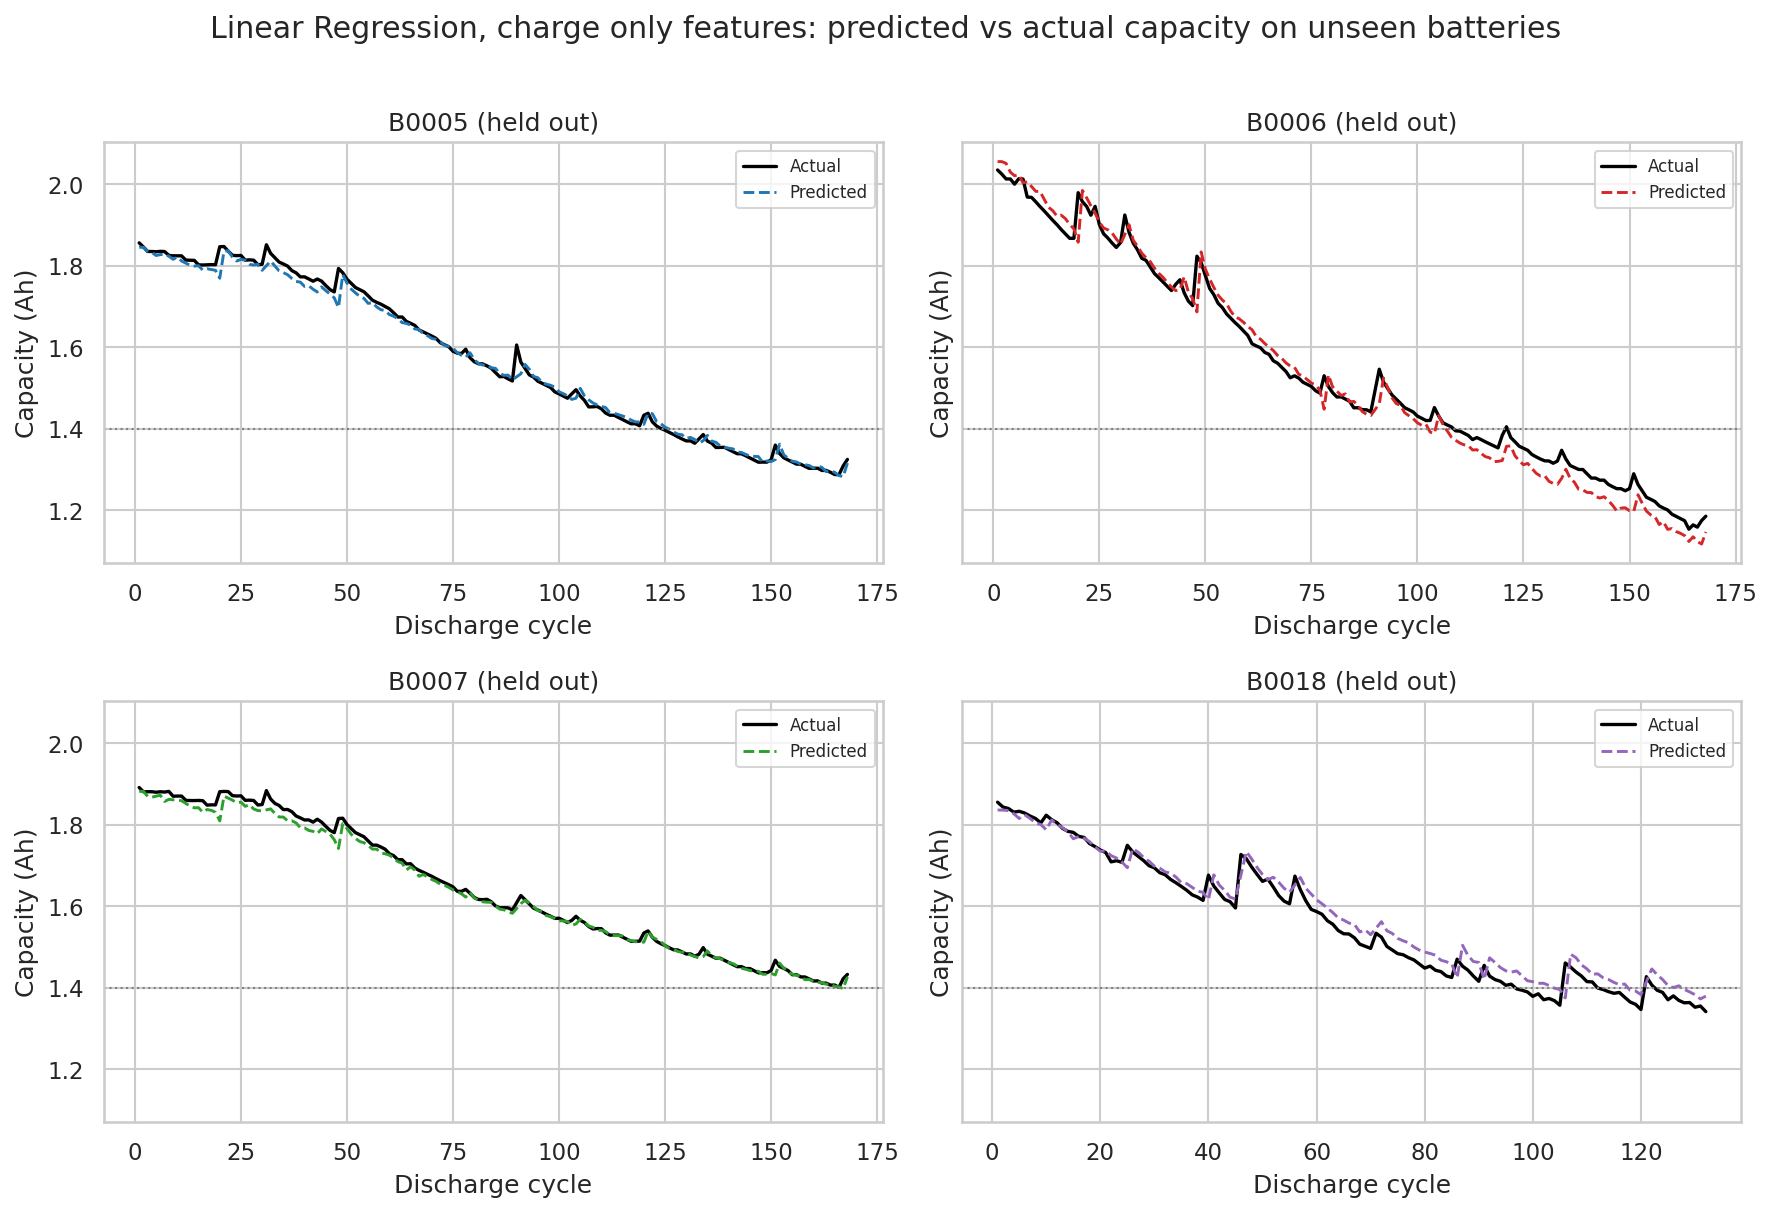

In [12]:
best = summary.iloc[0]
viz.plot_predictions(preds[preds.feature_set == best.feature_set], best.model, FIG_DIR,
                     label=f", {best.feature_set.split(' (')[0].lower()} features")
display(Image(FIG_DIR / "05_predicted_vs_actual.png"))

In [13]:
best_rows = metrics[(metrics.feature_set == best.feature_set) & (metrics.model == best.model)]
best_rows[["held_out_battery", "rmse_ah", "mape_pct", "r2", "actual_eol_cycle", "predicted_eol_cycle", "eol_error_cycles"]].round(4)

,held_out_battery,rmse_ah,mape_pct,r2,actual_eol_cycle,predicted_eol_cycle,eol_error_cycles
0,B0005,0.0164,0.6723,0.9925,125.0,126.0,1.0
3,B0006,0.0344,1.9300,0.9814,109.0,105.0,-4.0
6,B0007,0.0145,0.5560,0.9918,NaN,NaN,NaN
9,B0018,0.0294,1.7127,0.9638,97.0,104.0,7.0


For the three batteries that reached end of life (1.4 Ah), the predicted end-of-life cycle lands within 1, 4, and 7 cycles of the actual one.

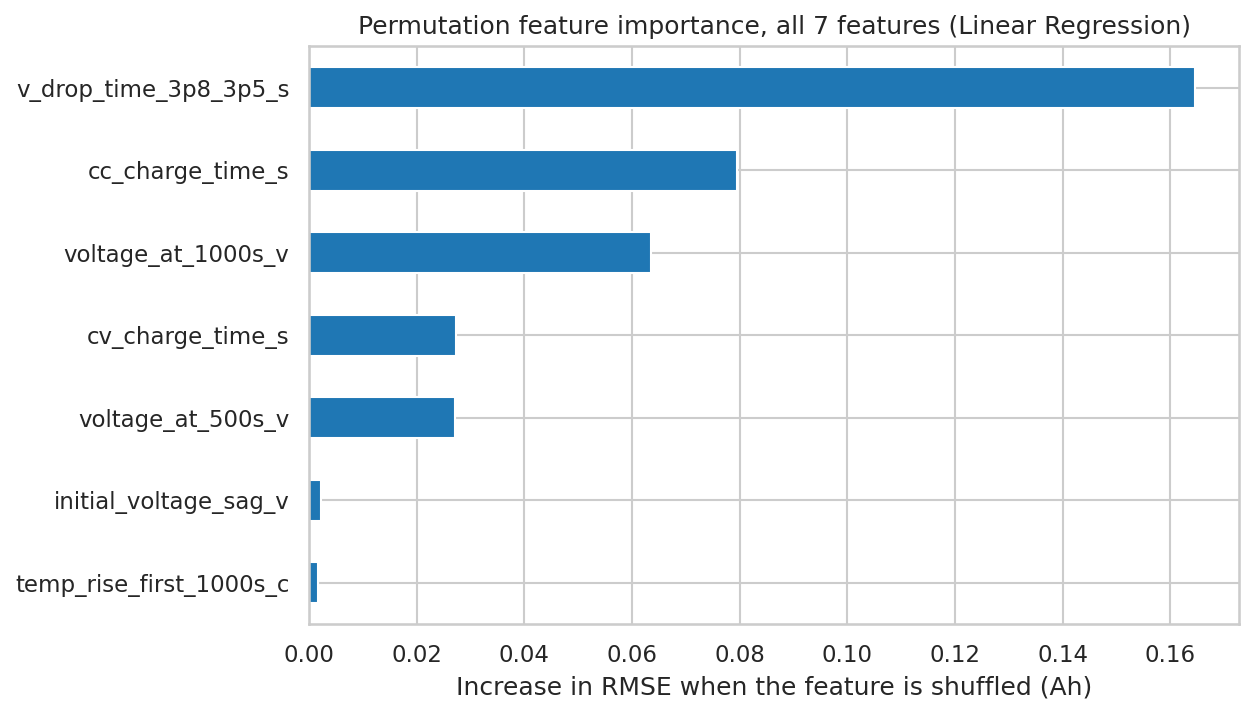

In [14]:
viz.plot_feature_importance(importance, "Linear Regression", FIG_DIR)
display(Image(FIG_DIR / "06_feature_importance.png"))

## 6. Conclusions
* **Result:** Linear Regression on two charge-phase features estimates capacity on never-seen batteries with **1.2% mean absolute percentage error (R² 0.98)**, averaged over four held-out cells.
* **Why it matters:** both features come from the charge cycle, so a battery management system could estimate health before the battery is even used, without a full discharge test.
* **Data quality drove the result.** Fixing abnormal charge cycles (without touching the target) cut error from 5.9% to 1.2% MAPE and raised R² from 0.66 to 0.98; removing a misleading temperature feature avoided learning rest time instead of health.
* **Simpler generalized better.** More features and more flexible models fit each battery's quirks rather than the shared aging pattern.

**Limitations and next steps**
* Four cells from one lab at room temperature (24 C). Results should be checked on larger datasets with varied temperatures and charge rates (for example the Stanford/MIT/Toyota fast-charging dataset).
* Remaining useful life here is estimated by applying the 1.4 Ah threshold to predicted capacity. A dedicated forecasting model (for example a Gaussian process or LSTM on the capacity trajectory) would forecast further ahead.
* Battery-level random effects or transfer learning could account for cell-to-cell offsets like B0006's.